# 큐의 구현

In [ ]:
class Node:
  def __init__(self, data):
    self.data = data
    self.next = None


class Queue:

  def __init__(self):
    self.front = None
    self.tail = None

  def enQueue(self, num):#9 3 12
    new = Node(num)
    if self.tail == None:
      self.front = new
      self.tail = new
    else:
      self.tail.next = new
      self.tail = new

  def deQueue(self):
    if self.front == None:
      print('dequeue FAIL: Queue is empty.')
      return None
    else:
      temp = self.front.data
      if self.front.next:
        self.front = self.front.next
      else:
        self.front = None
        self.tail = None
      return temp
    # 빈칸: 빈 큐일 때 "dequeue FAIL: Queue is empty." 출력
    # 빈칸: 노드가 한 개 남았을 때의 삭제
    # 빈칸: 두 개 이상의 노드가 남았을 때의 삭제

  def printQueue(self):
    cur = self.front
    print("Queue: ", end="")
    if cur == None:
      print("is empty.")
    else:
      while cur is not None:
        print(cur.data, end=" ")
        cur = cur.next
      print()



In [ ]:
Q = Queue()
Q.printQueue()

Queue: is empty.


In [ ]:
Q.enQueue(9)

In [ ]:
Q.printQueue()

Queue: 9 

In [ ]:
Q.enQueue(3)
Q.enQueue(12)
Q.enQueue(24)
Q.printQueue()

Queue: 9 3 12 24 

In [ ]:
Q.deQueue()

9

In [ ]:
Q.printQueue()

Queue: 3 12 24 

In [ ]:
print(f"삭제된 값: {Q.deQueue()}")
Q.printQueue()

삭제된 값: 3
Queue: 12 24 

# 큐 활용하기

Queue 클래스를 활용하여 놀이기구 줄 관리 프로그램을 완성하시오.

- 이름 입력하면 줄에 섬
- 5초마다 한 번 운행
- 한 번 운행 시 최대 3명 탑승 후 하차
- 'Q' 입력 시 종료

In [ ]:
from time import sleep
b=False
while True:
  q = Queue()
  for i in range(3):
    name = input()
    if name:
      if name == 'Q':
        b=True
        break
      q.enQueue(name)
  if b:
    break
  q.printQueue()
  sleep(5)
  for i in range(3):
    print(f"하차: {q.deQueue()}")

a
b
c
Queue: a b c 
하차: a
하차: b
하차: c
a
k
o
Queue: a k o 
하차: a
하차: k
하차: o


KeyboardInterrupt: Interrupted by user

# queue.Queue 활용하기

In [ ]:
from queue import Queue

q = Queue()
q.put(1)
q.put(2)
q.put(3)

In [ ]:
q.queue

deque([1, 2, 3])

In [ ]:
q.get()

1

In [ ]:
q.queue

deque([2, 3])

In [ ]:
q.empty()

False

In [ ]:
# 빈칸: queue.Queue를 활용하여, 앞서 만든 놀이기구 줄 관리 프로그램을 구현하시오.
from time import time
from queue import Queue
q = Queue()
t = time()
while True:
  name = input()
  if name == 'Q':
    break
  q.put(name)
  if time() - t > 5:
    for i in range(3):
      if q.empty():
        break
      print('하차:', q.get())
    t = time()



하차: a
하차: b
하차: c
하차: a


# Priority Queue(Heapq module)

In [ ]:
import heapq

In [ ]:
min_heap = []
heapq.heappush(min_heap, 2)
heapq.heappush(min_heap, 1)
heapq.heappush(min_heap, 6)
heapq.heappush(min_heap, 3)
heapq.heappush(min_heap, 7)

In [ ]:
heapq.heappop(min_heap)

1

In [ ]:
heapq.heappop(min_heap)

2

In [ ]:
heapq.heappop(min_heap)

3

In [ ]:
heapq.heappop(min_heap)

6

In [ ]:
heapq.heappop(min_heap)

7

## 큐 변형해서 우선순위 큐 구현하기

In [ ]:
class Node:
  def __init__(self, data):
    self.data = data
    self.next = None


class Queue:

  def __init__(self):
    self.front = None
    self.tail = None

  def enQueue(self, num):
      new = Node(num)

      if self.front is None:
          self.front = self.tail = new
          return

      if self.front.data > num:
          new.next = self.front
          self.front = new
          return

      cur = self.front
      while cur.next is not None and cur.next.data <= num:
          cur = cur.next

      new.next = cur.next
      cur.next = new

      if new.next is None:
          self.tail = new

  def deQueue(self):
    if self.front == None:
      print('dequeue FAIL: Queue is empty.')
      return None
    else:
      temp = self.front.data
      if self.front.next:
        self.front = self.front.next
      else:
        self.front = None
        self.tail = None
      return temp

  def printQueue(self):
    cur = self.front
    print("Queue: ", end="")
    if cur == None:
      print("is empty.")
    else:
      while cur is not None:
        print(cur.data, end=" ")
        cur = cur.next
      print()



In [ ]:
q = Queue()

In [ ]:
q.enQueue(6)
q.enQueue(4)
q.enQueue(5)

In [ ]:
for i in range(3):
  print(q.deQueue())

4
5
6


# Heap Tree

완전 이진 트리이기 때문에 앞에서부터 순차적인 탐색이 가능해 힙을 리스트로 구현

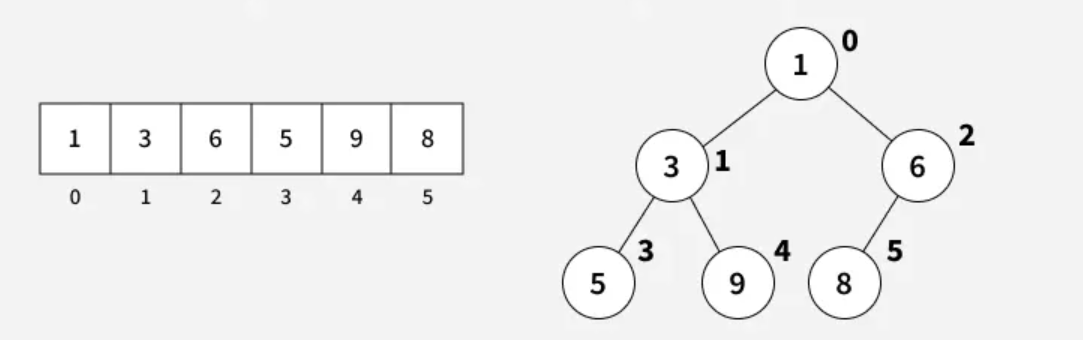



In [ ]:
class Heap:
  def __init__(self):
    self.heap = []

  def insert(self, num):#9 4 6
    self.heap.append(num)

    cur = len(self.heap)-1 #2
    while cur > 0:
      parent = (cur - 1) // 2
      if self.heap[parent] > num:
        self.heap[cur] = self.heap[parent]
        self.heap[parent] = num
        cur = parent

      else:
        break

  def pull(self):
    if not self.heap:
        return None
    if len(self.heap) == 1:
        return self.heap.pop()

    root = self.heap[0]
    self.heap[0] = self.heap.pop()

    cur = 0
    smallest = 0 #4
    while True:
        left = 2 * cur + 1 #1
        right = 2 * cur + 2#2

        if left < len(self.heap) and self.heap[left] < self.heap[smallest]:#1(6)<4
            smallest = left
        if right < len(self.heap) and self.heap[right] < self.heap[smallest]:#5<4
            smallest = right
        if smallest == cur:
            break

        self.heap[cur], self.heap[smallest] = self.heap[smallest], self.heap[cur]
        cur = smallest

    return root

  def printHeap(self):
    if not self.heap:
      return
    e=1
    for i in range(len(self.heap)):
      if i == 2**e-1:
        print()
        e += 1
      print(self.heap[i], end=' ')


In [ ]:
h = Heap()



In [ ]:
h.insert(9)
h.insert(4)
h.insert(6)
h.insert(5)
h.insert(61)
h.insert(46)
h.insert(7)
h.insert(8)
h.insert(1)
h.insert(11)
h.insert(19)
h.insert(87)
h.insert(65)
h.insert(20)

In [ ]:
h.heap

[1, 4, 6, 5, 11, 46, 7, 9, 8, 61, 19, 87, 65, 20]

In [ ]:
h.pull()

1

In [ ]:
h.printHeap()

4 
5 6 
8 11 46 7 
9 20 61 19 87 65 

# 다익스트라

기존에 노드를 사용하여 구현하려 했으나 노드 자체를 비교하려면 heap tree의 코드를 수정해야함

-> 노드 클래스 안에 다른 노드와 크기를 비교하는 메서드를 추가함 -> 코드만 길어지고 로직에 차이 없음


``` python
class Node:
  def __init__(self, index, dist):
    self.index = index
    self.dist = dist
  def __lt__(self, other):
    return self.dist < other.dist
  def __gt__(self, other):
    return self.dist > other.dist
```

튜플 형식으로 인접 행렬에 추가하고 튜플 비교를 통해 탐색함 -> 비용이 같으면 작은 숫자의 도시를 경유함

In [ ]:
def dijkstra():
  h = Heap()
  n, m = map(int, input().split())
  start_node = int(input())
  adj = [[] for i in range(n + 1)] # 인접 리스트로 각 도시간 관계 표시
  for i in range(m):
      u, v, w = map(int, input().split())
      adj[u].append((v, w))

  distance = [1e9] * (n + 1)
  distance[start_node] = 0

  h.insert((0, start_node))

  while True:
      current_data = h.pull()
      if current_data is None:
          break

      dist, now = current_data

      if distance[now] < dist:
          continue

      for next_node, weight in adj[now]:
          cost = dist + weight
          if cost < distance[next_node]:
              distance[next_node] = cost
              h.insert((cost, next_node))

  for i in range(1, n + 1):
      print(f"{i}번 도시까지: {distance[i]}")

dijkstra()

6 9
1
1 2 2
1 3 5
1 4 1
2 3 3
2 4 2
3 5 1
4 3 3
4 5 4
5 6 2
1번 도시까지: 0
2번 도시까지: 2
3번 도시까지: 4
4번 도시까지: 1
5번 도시까지: 5
6번 도시까지: 7


# 응급실

1. 대기열 입력 방식과 진료 방식이 과제 안내문에서 구체적으로 정해져 있지 않았기 때문에 프로그램의 전체 흐름을 실제 응급실 운영 방식과 유사하도록 설계하였다.

2. 새로운 환자가 접수되면 중증도, 나이, 의식 수준을 기준으로 우선순위 점수를 계산하여 힙 기반 대기열에 삽입하도록 하였다.

3. 대기열에는 항상 우선순위가 높은 환자가 먼저 처리될 수 있도록 Max 힙 구조를 사용하였다.

4. 또한 환자의 상태가 위급할수록 더 많은 처치 시간이 필요할 수 있다는 점을 반영하여 우선순위 점수에 비례하는 시간 동안 진료가 진행되도록 하였다.

5. 한 환자의 진료가 끝난 후 새로운 접수를 받으며 이때 임시 heap을 이용하여 bfs 순회대신 우선순위로 정렬된 대기열을 출력한다. 이를 위해 효율적으로 환자에게 번호를 매기는 방식을 택하였다.

6. 같은 우선순위 점수를 받은 두 환자에 대해서는 더 먼저 온사람이 먼저 진료를 받을 수 있도록 수정하였다.

In [ ]:
import time

In [ ]:
class Heap:
  def __init__(self):
    self.heap = []

  def insert(self, num):
    self.heap.append(num)
    cur = len(self.heap) - 1

    while cur > 0:
      parent = (cur - 1) // 2
      if self.heap[parent] < self.heap[cur]:   # 변경
        self.heap[cur], self.heap[parent] = self.heap[parent], self.heap[cur]
        cur = parent
      else:
        break

  def pull(self):
    if not self.heap:
      return None
    if len(self.heap) == 1:
      return self.heap.pop()

    root_val = self.heap[0]
    self.heap[0] = self.heap.pop()

    cur = 0
    while True:
      left = 2 * cur + 1
      right = 2 * cur + 2
      largest = cur

      if left < len(self.heap) and self.heap[left] > self.heap[largest]:  # 변경
        largest = left
      if right < len(self.heap) and self.heap[right] > self.heap[largest]:  # 변경
        largest = right

      if largest == cur:
        break

      self.heap[cur], self.heap[largest] = self.heap[largest], self.heap[cur]
      cur = largest

    return root_val

  def printHeap(self):
    if not self.heap:
        print("대기 환자가 없습니다.")
        return

    print("대기열:")

    temp = Heap()
    temp.heap = self.heap.copy()

    while temp.heap:
        priority, pid = temp.pull()
        print(-pid, end=" ")
    print()

In [ ]:
patient_id = -1
def PCalc() :
  c = ["정상", "혼미", "무의식"]
  priority = 0
  while 1 :
    severity = int(input("중증도를 입력하세요 1~5 \n"))
    if 1 <= severity <= 5:
      priority = priority + severity*10
      break
    else:
        print("범위 밖입니다. 다시 입력하세요.")
  while 1 :
    age = int(input("나이를 입력하세요."))
    if 1 <= age:
      if age < 11 or age > 64 :
        priority += 5
      break
    else:
        print("범위 밖입니다. 다시 입력하세요.")
  while 1 :
    loc = input("의식 상태 입력 (정상, 혼미, 무의식): ")
    if loc in c:
      priority += c.index(loc)*5
      break
    else:
        print("다시 입력하세요")
  return priority
def enqueue(emergency):
    global patient_id
    priority = PCalc()
    emergency.insert((priority, patient_id))
    print("환자", -1*patient_id, "번이 대기열에 추가되었습니다.")
    emergency.printHeap()
    patient_id -= 1
def dequeue(emergency):
    patient = emergency.pull()
    if patient:
        priority, pid = patient
        treat_time = priority * 0.1
        print(-1*pid, "번 환자 진료 시작 (우선순위 점수:", priority, ")")
        print("예상 진료시간:", treat_time, "초")
        time.sleep(treat_time)
        print("환자", -1*pid, "번 진료 완료")
    else:
        print("대기 환자가 없습니다.")


In [ ]:
emergency = Heap()
while True:
  m = input("\n환자 접수: enter, 종료: q ")
  if m == "q":
    print("시스템 종료")
    break
  n = int(input("몇 명을 접수하겠습니까?"))
  for i in range (n) :
    enqueue(emergency)
  dequeue(emergency)   # 바로 진료 시작


환자 접수: enter, 종료: q 
몇 명을 접수하겠습니까?3
중증도를 입력하세요 1~5 
5
나이를 입력하세요.5
의식 상태 입력 (정상, 혼미, 무의식): 정상
환자 1 번이 대기열에 추가되었습니다.
대기열:
1 
중증도를 입력하세요 1~5 
5
나이를 입력하세요.5
의식 상태 입력 (정상, 혼미, 무의식): 혼미
환자 2 번이 대기열에 추가되었습니다.
대기열:
2 1 
중증도를 입력하세요 1~5 
5
나이를 입력하세요.5
의식 상태 입력 (정상, 혼미, 무의식): 무의식
환자 3 번이 대기열에 추가되었습니다.
대기열:
3 2 1 
3 번 환자 진료 시작 (우선순위 점수: 65 )
예상 진료시간: 6.5 초
환자 3 번 진료 완료

환자 접수: enter, 종료: q 
몇 명을 접수하겠습니까?1
중증도를 입력하세요 1~5 
5
나이를 입력하세요.5
의식 상태 입력 (정상, 혼미, 무의식): 혼미
환자 4 번이 대기열에 추가되었습니다.
대기열:
2 4 1 
2 번 환자 진료 시작 (우선순위 점수: 60 )
예상 진료시간: 6.0 초
환자 2 번 진료 완료

환자 접수: enter, 종료: q 
몇 명을 접수하겠습니까?0
4 번 환자 진료 시작 (우선순위 점수: 60 )
예상 진료시간: 6.0 초
환자 4 번 진료 완료

환자 접수: enter, 종료: q 
몇 명을 접수하겠습니까?1
중증도를 입력하세요 1~5 
5
나이를 입력하세요.100
의식 상태 입력 (정상, 혼미, 무의식): 무의식
환자 5 번이 대기열에 추가되었습니다.
대기열:
5 1 
5 번 환자 진료 시작 (우선순위 점수: 65 )
예상 진료시간: 6.5 초
환자 5 번 진료 완료

환자 접수: enter, 종료: q q
시스템 종료


# 라면 공장

간단한 Greedy Algorithm을 통해 해결 가능하다.

- 현재 밀가루 양으로 버틸 수 있는 날짜 안에서 보급받을 수 있는 밀가루 양을 모두 확인
- 현재 밀가루 양이 목표 일수보다 작다면 현재 보급받을 수 있는 밀가루 양 중 가장 큰 양을 보급받기 <-- 이를 구현하기 위해 Max Heap이 필요함
- 현재 밀가루 양이 목요 일수 이상일 때까지 이를 반복함

In [ ]:
class Heap:
  def __init__(self):
    self.heap = []

  def insert(self, num):
    self.heap.append(num)

    cur = len(self.heap)-1
    while cur > 0:
      parent = (cur - 1) // 2
      if self.heap[parent] > num:
        self.heap[cur] = self.heap[parent]
        self.heap[parent] = num
        cur = parent

      else:
        break

  def pull(self):
    if not self.heap:
        return None
    if len(self.heap) == 1:
        return self.heap.pop()

    root = self.heap[0]
    self.heap[0] = self.heap.pop()

    cur = 0
    smallest = 0
    while True:
        left = 2 * cur + 1
        right = 2 * cur + 2

        if left < len(self.heap) and self.heap[left] < self.heap[smallest]:
            smallest = left
        if right < len(self.heap) and self.heap[right] < self.heap[smallest]:
            smallest = right
        if smallest == cur:
            break

        self.heap[cur], self.heap[smallest] = self.heap[smallest], self.heap[cur]
        cur = smallest

    return root

In [ ]:
flour = Heap()

# 변수 입력받기
stock = int(input())
dates = list(map(int, input().split()))
supplies = list(map(int, input().split()))
k = int(input())

N = 0  # 공급 횟수

while stock < k:  # stock 값이 k 이상일 때까지 반복
  for i in range(0, len(dates)):
    if dates[i] <= stock:
      flour.insert(- supplies[i])  # 현재 사용 중인 Heap은 Min Heap --> Max Heap처럼 작동하게 하기 위해 절댓값이 같은 음수를 대신 저장
      supplies[i] = 0

  stock -= flour.pull()  # 음수로 저장했으므로 += 대신 -= 사용
  N += 1  # 공급 횟수 +1

print(N)

4
4 10 15
20 5 10
30
2
